# 14. Explaining Anomaly Scores

Anomaly detection is rarely useful if it only says "this row is strange." Operators need to know **why** an alert fired, whether the explanation is stable enough to trust, what peer group the case should be compared against, and which parts of the explanation are merely model diagnostics rather than causal claims.

This notebook develops an explanation workflow for anomaly scores. We will use a synthetic platform-monitoring example, fit an unsupervised detector, build several explanation views, and translate the result into an analyst-facing packet.

## Learning Objectives

By the end of this notebook, you should be able to:

- Distinguish score explanation from root-cause proof.
- Decompose transparent anomaly scores into feature-level contributions.
- Use peer comparisons to make an anomaly explanation operationally meaningful.
- Fit a local surrogate around a focal alert to approximate a black-box anomaly score.
- Construct counterfactual threshold diagnostics without pretending they are causal interventions.
- Produce an alert explanation packet that is useful for review, escalation, suppression, or redesign.

## 1. Why Explanations Matter for Anomaly Detection

A high anomaly score is an invitation to investigate, not a finished diagnosis. The alert may reflect a true incident, an expected product launch, instrumentation drift, a segment mix shift, a rare but harmless customer pattern, or a detector defect.

| Explanation question | Why it matters | Example artifact |
|---|---|---|
| What made the score high? | Analyst triage needs direction | Feature contributions and local score drivers |
| Compared with whom? | A checkout endpoint should not be compared blindly with a batch export endpoint | Peer-group percentiles and reference bands |
| Is the explanation stable? | Unstable explanations are hard to operationalize | Perturbation or peer-set sensitivity |
| What would lower the score? | Helps distinguish threshold proximity from extreme deviation | Counterfactual movement toward reference behavior |
| What should the analyst do? | Explanation must support action | Escalate, suppress, monitor, audit, or redesign |

Rad et al. (2021) note that anomaly detection and explanation discovery have often been treated separately, even though enterprise users need human-readable explanations for detected events. Kim et al. (2021) make a similar point in sensor monitoring: unsupervised anomaly detectors may flag abnormal behavior, but operators need interpretable evidence about why a case was classified as anomalous.

## 2. Mathematical Setup

Let $x_i \in \mathbb{R}^p$ be the feature vector for monitored unit $i$, and let $s(x_i)$ be an anomaly score where larger values are more suspicious. A threshold policy creates an alert when

$$
s(x_i) \geq \tau.
$$

An explanation should be tied to this score and threshold. For a transparent additive score, suppose

$$
s_{\mathrm{add}}(x_i) = \sum_{j=1}^{p} c_j(x_i), \qquad c_j(x_i) \geq 0.
$$

Then $c_j(x_i)$ can be read as the feature-level contribution to the anomaly score. For example, if $z_{ij}$ is a robust standardized feature,

$$
z_{ij} = \frac{x_{ij} - \mathrm{median}_{\mathrm{ref}}(X_j)}{1.4826 \cdot \mathrm{MAD}_{\mathrm{ref}}(X_j)},
$$

a simple distance-style score is

$$
s_{\mathrm{dist}}(x_i) = \sqrt{\sum_{j=1}^{p} w_j z_{ij}^{2}}.
$$

The normalized contribution share is

$$
q_j(x_i) = \frac{w_j z_{ij}^{2}}{\sum_{\ell=1}^{p} w_{\ell} z_{i\ell}^{2}}.
$$

For a black-box score $s(x)$, we can fit a local surrogate around a focal alert $x_0$. A LIME-style explanation solves

$$
\hat g = \arg\min_{g \in G} \sum_{m=1}^{M} \pi_{x_0}(\tilde x_m)\left[s(\tilde x_m) - g(\tilde x_m)\right]^2 + \lambda \Omega(g),
$$

where $\tilde x_m$ are perturbations near $x_0$, $\pi_{x_0}$ gives higher weight to nearby perturbations, and $g$ is a simple local model such as a sparse or regularized linear model. Ribeiro et al. (2016) popularized this local surrogate idea for explaining arbitrary classifiers. Lundberg and Lee (2017) connect additive feature attributions to Shapley-value reasoning. In this notebook we implement the local-surrogate logic directly so the mechanics remain visible.

## 3. Explanation Is Not Causation

A feature attribution answers a model question:

$$
\text{Which feature values made } s(x_i) \text{ high under this scoring rule?}
$$

It does **not** automatically answer a causal question:

$$
\text{Which real-world intervention would prevent the incident?}
$$

This distinction is especially important in anomaly detection. A spike in latency, retry rate, and queue depth may all appear in the explanation, but only one may be upstream. The explanation tells the analyst where to look first. The root-cause claim requires additional system knowledge, logs, experiments, traces, or causal process understanding.

In [1]:
# Section focus: 3. Explanation Is Not Causation.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.linear_model import Ridge
from sklearn.metrics import average_precision_score, precision_recall_curve, roc_auc_score
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import RobustScaler

repo_root = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / 'notebooks' / '_shared' / 'display.py').exists())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from notebooks._shared.display import smart_display

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 130
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['legend.fontsize'] = 8.5
plt.rcParams['legend.title_fontsize'] = 9
pd.set_option('display.max_columns', 140)

RANDOM_SEED = 51414
rng = np.random.default_rng(RANDOM_SEED)

PALETTE = {
    'normal': '#6b7280',
    'dependency_outage': '#7c3aed',
    'credential_attack': '#dc2626',
    'schema_drift': '#0f766e',
    'benign_campaign_spike': '#f59e0b',
    'score': '#2563eb',
    'threshold': '#111827',
    'positive': '#b91c1c',
    'negative': '#047857',
}

## 4. Synthetic Case: Platform Health Alerts

We will simulate endpoint-hour telemetry from a digital platform. Each row summarizes one endpoint in one hour. The detector sees numeric telemetry such as latency, errors, retries, authentication failures, volume changes, schema mismatches, payload size, dependency timeouts, and queue depth.

Three true anomaly patterns appear in the monitoring period:

- **Dependency outage:** high latency, timeouts, retries, errors, and queue depth.
- **Credential attack:** high authentication failures, abnormal geographic entropy, and login volume.
- **Schema drift:** high schema mismatch, payload shifts, and ingestion errors.

A fourth pattern is intentionally **not** a true incident:

- **Benign campaign spike:** traffic and queue load rise during a planned campaign.

That benign case matters. A detector can be technically correct that a row is unusual while still being operationally wrong to escalate it as an incident.

In [2]:
# Section focus: 4. Synthetic Case: Platform Health Alerts.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def simulate_platform_health(seed=RANDOM_SEED, n_reference=2400, n_monitor=4200):
    """Create a simulated platform health data set for the 14. Explaining Anomaly Scores case study.
    
    Parameters
    ----------
    seed : object
        Random seed used to make the simulation reproducible.
    n_reference : object
        Count or size setting for the platform health calculation.
    n_monitor : object
        Count or size setting for the platform health calculation.
    
    Returns
    -------
    object
        pandas.DataFrame containing the tabular result produced by this function.
    """
    rng = np.random.default_rng(seed)
    endpoints = np.array(['checkout', 'login', 'payout', 'reporting', 'ingestion'])
    endpoint_probs = np.array([0.28, 0.24, 0.15, 0.16, 0.17])
    regions = np.array(['us', 'eu', 'apac', 'latam'])
    region_probs = np.array([0.46, 0.25, 0.20, 0.09])
    base_latency = {'checkout': 220, 'login': 120, 'payout': 260, 'reporting': 360, 'ingestion': 300}
    base_payload = {'checkout': 0.55, 'login': 0.18, 'payout': 0.70, 'reporting': 1.20, 'ingestion': 1.45}
    base_volume = {'checkout': 1.15, 'login': 1.35, 'payout': 0.75, 'reporting': 0.65, 'ingestion': 0.90}

    rows = []
    total = n_reference + n_monitor
    start = pd.Timestamp('2026-09-01')
    for i in range(total):
        split = 'reference' if i < n_reference else 'monitoring'
        hour = start + pd.Timedelta(hours=i // len(endpoints))
        endpoint = rng.choice(endpoints, p=endpoint_probs)
        region = rng.choice(regions, p=region_probs)
        hour_of_day = hour.hour
        day = (hour - start).days
        is_business = 8 <= hour_of_day <= 18
        load = rng.gamma(shape=2.2, scale=0.45)
        endpoint_load = base_volume[endpoint] * (1.18 if is_business else 0.82) * rng.lognormal(0, 0.18)

        anomaly_kind = 'normal'
        if split == 'monitoring':
            p = rng.random()
            if 34 <= day <= 36 and endpoint in ['checkout', 'payout'] and p < 0.32:
                anomaly_kind = 'dependency_outage'
            elif 45 <= day <= 48 and endpoint == 'login' and p < 0.36:
                anomaly_kind = 'credential_attack'
            elif 55 <= day <= 57 and endpoint == 'ingestion' and p < 0.30:
                anomaly_kind = 'schema_drift'
            elif 50 <= day <= 51 and endpoint in ['checkout', 'reporting'] and p < 0.42:
                anomaly_kind = 'benign_campaign_spike'

        latency = base_latency[endpoint] * rng.lognormal(0, 0.20) * (1 + 0.08 * load)
        error_rate = rng.beta(1.2, 85) * 100
        retry_rate = rng.beta(1.0, 70) * 100
        auth_fail_rate = rng.beta(1.3, 90) * 100
        geo_entropy = np.clip(rng.normal(1.8 + 0.25 * (region == 'apac'), 0.28), 0.3, 3.5)
        volume_ratio = endpoint_load * rng.lognormal(0, 0.16)
        schema_mismatch = rng.beta(0.8, 130) * 100
        payload_mb = base_payload[endpoint] * rng.lognormal(0, 0.25)
        dependency_timeout = rng.beta(0.8, 120) * 100
        queue_depth = rng.gamma(shape=2.0 + 0.5 * is_business, scale=8.0) * endpoint_load

        if anomaly_kind == 'dependency_outage':
            latency *= rng.uniform(2.4, 4.2)
            error_rate += rng.uniform(4.5, 10.5)
            retry_rate += rng.uniform(7.0, 17.0)
            dependency_timeout += rng.uniform(8.0, 24.0)
            queue_depth *= rng.uniform(3.0, 6.0)
        elif anomaly_kind == 'credential_attack':
            auth_fail_rate += rng.uniform(18.0, 42.0)
            geo_entropy += rng.uniform(1.0, 2.0)
            volume_ratio *= rng.uniform(2.1, 4.2)
            error_rate += rng.uniform(0.6, 2.4)
        elif anomaly_kind == 'schema_drift':
            schema_mismatch += rng.uniform(8.0, 28.0)
            payload_mb *= rng.uniform(2.1, 4.8)
            error_rate += rng.uniform(2.0, 7.5)
            retry_rate += rng.uniform(1.5, 5.5)
        elif anomaly_kind == 'benign_campaign_spike':
            volume_ratio *= rng.uniform(2.0, 3.5)
            queue_depth *= rng.uniform(1.5, 2.8)
            latency *= rng.uniform(1.10, 1.35)

        true_anomaly = anomaly_kind in ['dependency_outage', 'credential_attack', 'schema_drift']
        expected_change = anomaly_kind == 'benign_campaign_spike'
        incident_cost = 0.0
        if anomaly_kind == 'dependency_outage':
            incident_cost = rng.normal(42000, 8000)
        elif anomaly_kind == 'credential_attack':
            incident_cost = rng.normal(36000, 9000)
        elif anomaly_kind == 'schema_drift':
            incident_cost = rng.normal(52000, 11000)

        rows.append({
            'timestamp': hour,
            'split': split,
            'endpoint': endpoint,
            'region': region,
            'anomaly_kind': anomaly_kind,
            'true_anomaly': true_anomaly,
            'expected_change': expected_change,
            'incident_cost': max(0, incident_cost),
            'latency_p95_ms': latency,
            'error_rate_pct': np.clip(error_rate, 0, 100),
            'retry_rate_pct': np.clip(retry_rate, 0, 100),
            'auth_fail_rate_pct': np.clip(auth_fail_rate, 0, 100),
            'geo_entropy': np.clip(geo_entropy, 0, 6),
            'volume_ratio': np.clip(volume_ratio, 0.05, 8),
            'schema_mismatch_pct': np.clip(schema_mismatch, 0, 100),
            'payload_mb': np.clip(payload_mb, 0.02, 20),
            'dependency_timeout_pct': np.clip(dependency_timeout, 0, 100),
            'queue_depth': np.clip(queue_depth, 0, 400),
        })
    return pd.DataFrame(rows)

feature_cols = [
    'latency_p95_ms',
    'error_rate_pct',
    'retry_rate_pct',
    'auth_fail_rate_pct',
    'geo_entropy',
    'volume_ratio',
    'schema_mismatch_pct',
    'payload_mb',
    'dependency_timeout_pct',
    'queue_depth',
]

feature_names = {
    'latency_p95_ms': 'Latency p95',
    'error_rate_pct': 'Error rate',
    'retry_rate_pct': 'Retry rate',
    'auth_fail_rate_pct': 'Auth fail rate',
    'geo_entropy': 'Geo entropy',
    'volume_ratio': 'Volume ratio',
    'schema_mismatch_pct': 'Schema mismatch',
    'payload_mb': 'Payload size',
    'dependency_timeout_pct': 'Dependency timeout',
    'queue_depth': 'Queue depth',
}

feature_area = {
    'latency_p95_ms': 'Reliability',
    'error_rate_pct': 'Reliability',
    'retry_rate_pct': 'Reliability',
    'auth_fail_rate_pct': 'Security',
    'geo_entropy': 'Security',
    'volume_ratio': 'Demand context',
    'schema_mismatch_pct': 'Data quality',
    'payload_mb': 'Data quality',
    'dependency_timeout_pct': 'Reliability',
    'queue_depth': 'Capacity',
}

feature_actionability = {
    'latency_p95_ms': 'Diagnostic',
    'error_rate_pct': 'Diagnostic',
    'retry_rate_pct': 'Diagnostic',
    'auth_fail_rate_pct': 'Investigate security controls',
    'geo_entropy': 'Investigate traffic source',
    'volume_ratio': 'Check release or campaign calendar',
    'schema_mismatch_pct': 'Inspect upstream schema contract',
    'payload_mb': 'Inspect payload source and contract',
    'dependency_timeout_pct': 'Inspect dependency health',
    'queue_depth': 'Check capacity and backlog',
}

platform = simulate_platform_health()
reference = platform[platform['split'].eq('reference')].copy()
monitor = platform[platform['split'].eq('monitoring')].copy()

summary = pd.DataFrame([
    {
        'split': split,
        'rows': len(group),
        'true_anomaly_rate': group['true_anomaly'].mean(),
        'expected_change_rate': group['expected_change'].mean(),
        'mean_latency': group['latency_p95_ms'].mean(),
        'mean_error_rate': group['error_rate_pct'].mean(),
        'mean_auth_fail_rate': group['auth_fail_rate_pct'].mean(),
    }
    for split, group in platform.groupby('split')
])

kind_summary = (
    monitor.groupby('anomaly_kind')
    .agg(
        rows=('anomaly_kind', 'size'),
        true_anomaly_rate=('true_anomaly', 'mean'),
        expected_change_rate=('expected_change', 'mean'),
        mean_incident_cost=('incident_cost', 'mean'),
        mean_latency=('latency_p95_ms', 'mean'),
        mean_auth_fail=('auth_fail_rate_pct', 'mean'),
        mean_schema_mismatch=('schema_mismatch_pct', 'mean'),
    )
    .reset_index()
    .sort_values(['true_anomaly_rate', 'rows'], ascending=[False, False])
)

smart_display(summary.style.format({
    'true_anomaly_rate': '{:.2%}',
    'expected_change_rate': '{:.2%}',
    'mean_latency': '{:.1f}',
    'mean_error_rate': '{:.2f}%',
    'mean_auth_fail_rate': '{:.2f}%',
}))
smart_display(kind_summary.style.format({
    'true_anomaly_rate': '{:.1%}',
    'expected_change_rate': '{:.1%}',
    'mean_incident_cost': '${:,.0f}',
    'mean_latency': '{:.1f}',
    'mean_auth_fail': '{:.1f}%',
    'mean_schema_mismatch': '{:.1f}%',
}), max_width='460px')

,split,rows,true_anomaly_rate,expected_change_rate,mean_latency,mean_error_rate,mean_auth_fail_rate
0,monitoring,4200,1.71%,1.05%,269.5,1.48%,1.61%
1,reference,2400,0.00%,0.00%,262.6,1.38%,1.39%


,anomaly_kind,rows,true_anomaly_rate,expected_change_rate,mean_incident_cost,mean_latency,mean_auth_fail,mean_schema_mismatch
2,dependency_outage,43,100.0%,0.0%,"$43,877",903.5,1.5%,0.6%
1,credential_attack,29,100.0%,0.0%,"$36,338",133.8,30.4%,0.6%
3,normal,4084,0.0%,0.0%,$0,262.8,1.4%,0.6%
0,benign_campaign_spike,44,0.0%,100.0%,$0,355.6,1.6%,0.7%


The simulation creates exactly the type of ambiguity that makes explanations necessary. The monitoring period contains true incidents and expected business changes. An explanation workflow should therefore help the analyst separate:

- **score drivers**: which measurements made the detector suspicious;
- **peer context**: whether those measurements are abnormal for this endpoint type;
- **operational interpretation**: whether the abnormality should trigger incident response or suppression.

## 5. Fit an Unsupervised Detector and Score Policy

We will train the detector only on the reference period. The score policy combines two components:

1. **Isolation score:** a black-box-ish unsupervised score from Isolation Forest (Liu et al., 2008).
2. **Robust distance score:** a transparent distance from reference medians.

The combined score is useful pedagogically because it lets us explain one part exactly and another part approximately.

In [3]:
# Section focus: 5. Fit an Unsupervised Detector and Score Policy.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

scaler = RobustScaler(quantile_range=(25, 75))
Z_ref = scaler.fit_transform(reference[feature_cols])
Z_all = scaler.transform(platform[feature_cols])
Z_monitor = scaler.transform(monitor[feature_cols])

iso = IsolationForest(
    n_estimators=350,
    max_samples=384,
    contamination=0.04,
    random_state=RANDOM_SEED,
)
iso.fit(Z_ref)

weights = pd.Series({
    'latency_p95_ms': 1.10,
    'error_rate_pct': 1.20,
    'retry_rate_pct': 1.05,
    'auth_fail_rate_pct': 1.25,
    'geo_entropy': 0.80,
    'volume_ratio': 0.75,
    'schema_mismatch_pct': 1.25,
    'payload_mb': 0.85,
    'dependency_timeout_pct': 1.25,
    'queue_depth': 0.85,
})


def robust_center_scale(values):
    """Carry out the robust center scale step used in the 14. Explaining Anomaly Scores workflow.
    
    Parameters
    ----------
    values : object
        The values setting that controls the robust center scale calculation in this notebook.
    
    Returns
    -------
    object
        Tuple of outputs from this workflow, usually data, fitted objects, or diagnostics used by later cells.
    """
    values = np.asarray(values, dtype=float)
    center = np.median(values)
    mad = np.median(np.abs(values - center))
    scale = 1.4826 * mad
    if not np.isfinite(scale) or scale < 1e-8:
        scale = np.std(values) + 1e-8
    return center, scale


def robust_distance_from_z(Z):
    """Carry out the robust distance from z step used in the 14. Explaining Anomaly Scores workflow.
    
    Parameters
    ----------
    Z : object
        The Z setting that controls the robust distance from z calculation in this notebook.
    
    Returns
    -------
    object
        Numeric diagnostic, score, or transformed value from the robust distance from z calculation.
    """
    Z = np.asarray(Z, dtype=float)
    return np.sqrt(np.maximum((Z ** 2) @ weights.loc[feature_cols].to_numpy(), 0))

ref_if_raw = -iso.decision_function(Z_ref)
ref_dist_raw = robust_distance_from_z(Z_ref)
if_center, if_scale = robust_center_scale(ref_if_raw)
dist_center, dist_scale = robust_center_scale(ref_dist_raw)


def score_from_z(Z):
    """Score from z for the 14. Explaining Anomaly Scores workflow.
    
    Parameters
    ----------
    Z : object
        The Z setting that controls the from z calculation in this notebook.
    
    Returns
    -------
    object
        Intermediate result produced by the from z calculation and reused by later cells.
    """
    Z = np.asarray(Z, dtype=float)
    if_component = (-iso.decision_function(Z) - if_center) / if_scale
    dist_component = (robust_distance_from_z(Z) - dist_center) / dist_scale
    return 0.62 * if_component + 0.38 * dist_component

platform = platform.copy()
platform['if_score_component'] = (-iso.decision_function(Z_all) - if_center) / if_scale
platform['distance_score_component'] = (robust_distance_from_z(Z_all) - dist_center) / dist_scale
platform['anomaly_score'] = score_from_z(Z_all)
platform['distance_raw'] = robust_distance_from_z(Z_all)

monitor = platform[platform['split'].eq('monitoring')].copy()
reference = platform[platform['split'].eq('reference')].copy()

threshold = np.quantile(reference['anomaly_score'], 0.995)
monitor['alert'] = monitor['anomaly_score'].ge(threshold)
platform.loc[monitor.index, 'alert'] = monitor['alert']

y_true = monitor['true_anomaly'].astype(int).to_numpy()
score = monitor['anomaly_score'].to_numpy()
precision, recall, _ = precision_recall_curve(y_true, score)
policy_summary = pd.DataFrame([
    {
        'threshold_source': '99.5th percentile of reference scores',
        'threshold': threshold,
        'monitoring_alert_rate': monitor['alert'].mean(),
        'precision_among_alerts': monitor.loc[monitor['alert'], 'true_anomaly'].mean(),
        'expected_change_share_among_alerts': monitor.loc[monitor['alert'], 'expected_change'].mean(),
        'roc_auc_teaching_only': roc_auc_score(y_true, score),
        'average_precision_teaching_only': average_precision_score(y_true, score),
    }
])

smart_display(policy_summary.style.format({
    'threshold': '{:.2f}',
    'monitoring_alert_rate': '{:.1%}',
    'precision_among_alerts': '{:.1%}',
    'expected_change_share_among_alerts': '{:.1%}',
    'roc_auc_teaching_only': '{:.3f}',
    'average_precision_teaching_only': '{:.3f}',
}), max_width='460px')

,threshold_source,threshold,monitoring_alert_rate,precision_among_alerts,expected_change_share_among_alerts,roc_auc_teaching_only,average_precision_teaching_only
0,99.5th percentile of reference scores,4.10,2.3%,73.5%,8.2%,1.000,1.000


The practical reading of Fit an Unsupervised Detector and Score Policy is whether the flagged cases point to an action a team can defend.


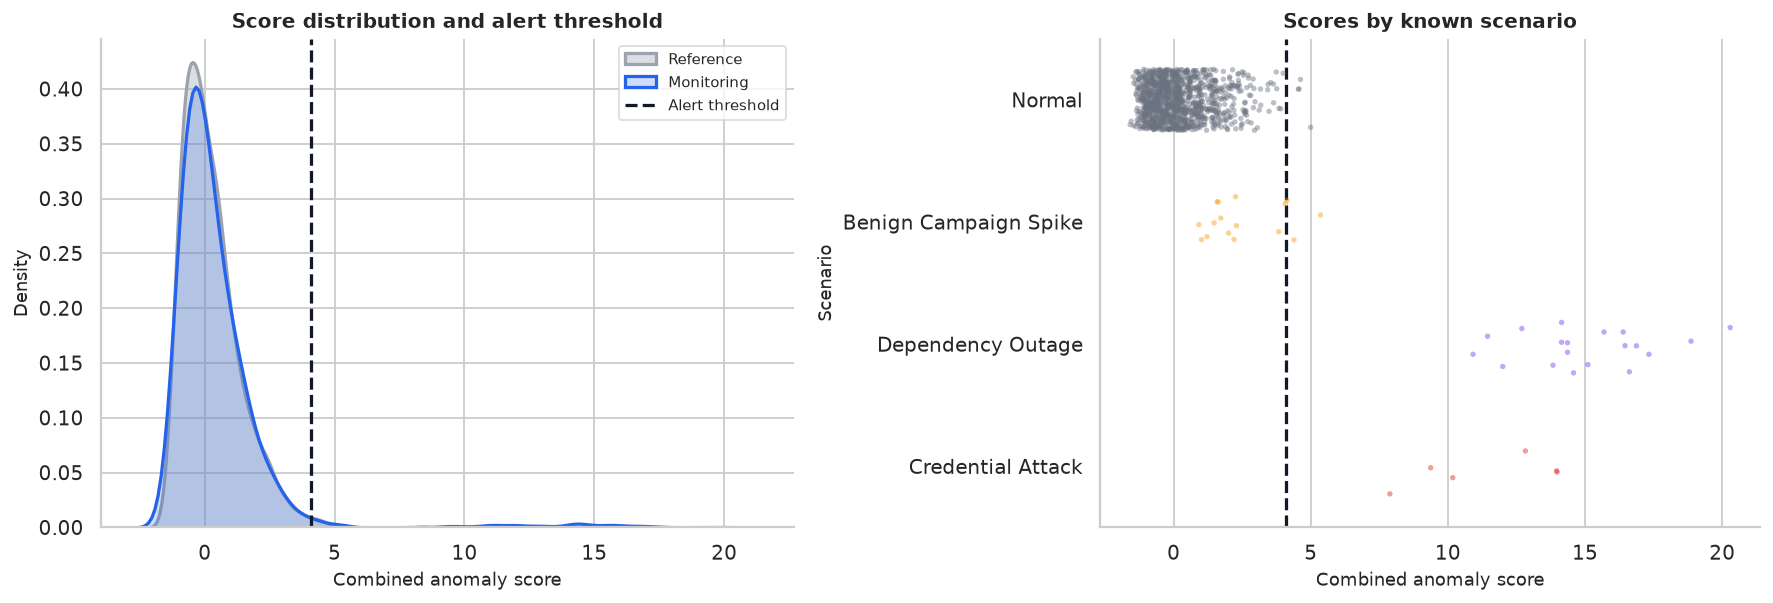

In [4]:
# Section focus: 5. Fit an Unsupervised Detector and Score Policy.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

fig, axes = plt.subplots(1, 2, figsize=(13.8, 4.8), gridspec_kw={'width_ratios': [1.05, 1]})

sns.kdeplot(reference['anomaly_score'], fill=True, color='#9ca3af', alpha=0.35, linewidth=1.8, label='Reference', ax=axes[0])
sns.kdeplot(monitor['anomaly_score'], fill=True, color=PALETTE['score'], alpha=0.22, linewidth=1.8, label='Monitoring', ax=axes[0])
axes[0].axvline(threshold, color=PALETTE['threshold'], linestyle='--', linewidth=1.8, label='Alert threshold')
axes[0].set_title('Score distribution and alert threshold')
axes[0].set_xlabel('Combined anomaly score')
axes[0].set_ylabel('Density')
axes[0].legend(frameon=True, facecolor='white', edgecolor='#d1d5db')

plot_kinds = ['normal', 'benign_campaign_spike', 'dependency_outage', 'credential_attack', 'schema_drift']
plot_df = monitor[monitor['anomaly_kind'].isin(plot_kinds)].copy()
plot_df['kind_label'] = plot_df['anomaly_kind'].str.replace('_', ' ').str.title()
sns.stripplot(
    data=plot_df.sample(min(len(plot_df), 1200), random_state=RANDOM_SEED),
    x='anomaly_score',
    y='kind_label',
    hue='anomaly_kind',
    palette=PALETTE,
    alpha=0.45,
    size=3.0,
    jitter=0.25,
    ax=axes[1],
)
axes[1].axvline(threshold, color=PALETTE['threshold'], linestyle='--', linewidth=1.8)
axes[1].set_title('Scores by known scenario')
axes[1].set_xlabel('Combined anomaly score')
axes[1].set_ylabel('Scenario')
axes[1].legend([], [], frameon=False)

sns.despine(fig=fig)
plt.tight_layout()
plt.show()

The threshold is calibrated on the reference period. In production, this would be an operational choice tied to review capacity and tolerance for missed incidents. Here the labels are available only to teach the consequences of the threshold.

Notice the central ambiguity: benign campaign spikes can cross the threshold. They are unusual relative to reference behavior, but they are not necessarily incidents. This is exactly why the explanation packet must include operational context, alongside feature attributions.

## 6. Select a Focal Alert

We will choose a high-scoring monitoring alert that is a true anomaly and explain it from several angles. The same workflow would also be valuable for a benign but high-scoring case, because explanation can support suppression.

In [5]:
# Section focus: 6. Select a Focal Alert.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

alert_candidates = monitor[monitor['alert'] & monitor['true_anomaly']].copy()
focal_idx = alert_candidates.sort_values('anomaly_score', ascending=False).index[2]
focal = platform.loc[focal_idx].copy()
focal_z = pd.Series(Z_all[platform.index.get_loc(focal_idx)], index=feature_cols)

focal_summary = pd.DataFrame([
    {
        'field': 'timestamp',
        'value': str(focal['timestamp']),
    },
    {
        'field': 'endpoint',
        'value': focal['endpoint'],
    },
    {
        'field': 'region',
        'value': focal['region'],
    },
    {
        'field': 'known scenario in simulation',
        'value': focal['anomaly_kind'],
    },
    {
        'field': 'combined anomaly score',
        'value': f"{focal['anomaly_score']:.2f}",
    },
    {
        'field': 'alert threshold',
        'value': f"{threshold:.2f}",
    },
    {
        'field': 'score gap above threshold',
        'value': f"{focal['anomaly_score'] - threshold:.2f}",
    },
])

smart_display(focal_summary, max_width='520px')

,field,value
0,timestamp,2026-10-07 11:00:00
1,endpoint,checkout
2,region,apac
3,known scenario in simulation,dependency_outage
4,combined anomaly score,18.86
5,alert threshold,4.10
6,score gap above threshold,14.77


For Select a Focal Alert, separate unusual behavior from useful triage. The alert is valuable only when it changes the next review step.


## 7. Peer Comparison: Abnormal Relative to What?

Anomaly explanations should be contextual. A `reporting` endpoint may normally have larger payloads than a `login` endpoint. A global percentile can therefore be misleading. We will compare the focal alert with reference rows from the same endpoint.

In [6]:
# Section focus: 7. Peer Comparison: Abnormal Relative to What?.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

peer_mask = reference['endpoint'].eq(focal['endpoint'])
peer_reference = reference[peer_mask].copy()
if len(peer_reference) < 100:
    peer_reference = reference.copy()

peer_stats = []
for feature in feature_cols:
    values = peer_reference[feature]
    focal_value = focal[feature]
    percentile = (values.le(focal_value).mean())
    q25, q50, q75 = values.quantile([0.25, 0.50, 0.75])
    peer_stats.append({
        'feature': feature_names[feature],
        'raw_feature': feature,
        'area': feature_area[feature],
        'focal_value': focal_value,
        'peer_median': q50,
        'peer_iqr': q75 - q25,
        'peer_percentile': percentile,
        'robust_z_reference': focal_z[feature],
        'actionability': feature_actionability[feature],
    })
peer_table = pd.DataFrame(peer_stats)
peer_table['extremeness'] = (peer_table['peer_percentile'] - 0.5).abs()
peer_table['abs_robust_z_reference'] = peer_table['robust_z_reference'].abs()
peer_table = peer_table.sort_values(['extremeness', 'abs_robust_z_reference'], ascending=False)

smart_display(peer_table.drop(columns=['raw_feature', 'extremeness', 'abs_robust_z_reference']).head(10).style.format({
    'focal_value': '{:.2f}',
    'peer_median': '{:.2f}',
    'peer_iqr': '{:.2f}',
    'peer_percentile': '{:.1%}',
    'robust_z_reference': '{:.2f}',
}), max_width='520px')

,feature,area,focal_value,peer_median,peer_iqr,peer_percentile,robust_z_reference,actionability
8,Dependency timeout,Reliability,25.49,0.40,0.77,100.0%,31.32,Inspect dependency health
1,Error rate,Reliability,10.82,1.06,1.38,100.0%,7.07,Diagnostic
2,Retry rate,Reliability,10.74,0.96,1.42,100.0%,6.43,Diagnostic
0,Latency p95,Reliability,1038.30,237.02,67.35,100.0%,5.14,Diagnostic
9,Queue depth,Capacity,102.18,16.58,18.40,99.7%,5.23,Check capacity and backlog
4,Geo entropy,Security,2.36,1.86,0.42,95.3%,1.28,Investigate traffic source
7,Payload size,Data quality,0.76,0.54,0.19,91.0%,0.16,Inspect payload source and contract
5,Volume ratio,Demand context,1.03,1.12,0.44,37.0%,0.11,Check release or campaign calendar
3,Auth fail rate,Security,1.29,1.06,1.37,57.6%,0.17,Investigate security controls
6,Schema mismatch,Data quality,0.48,0.40,0.71,55.6%,0.09,Inspect upstream schema contract


Read the result through the lens of alert quality. In Peer Comparison: Abnormal Relative to What?, high scores, unusual clusters, or shifted distributions should be connected to the cost of missed incidents and false alarms. A useful detector is one whose outputs can be investigated, explained, and governed.


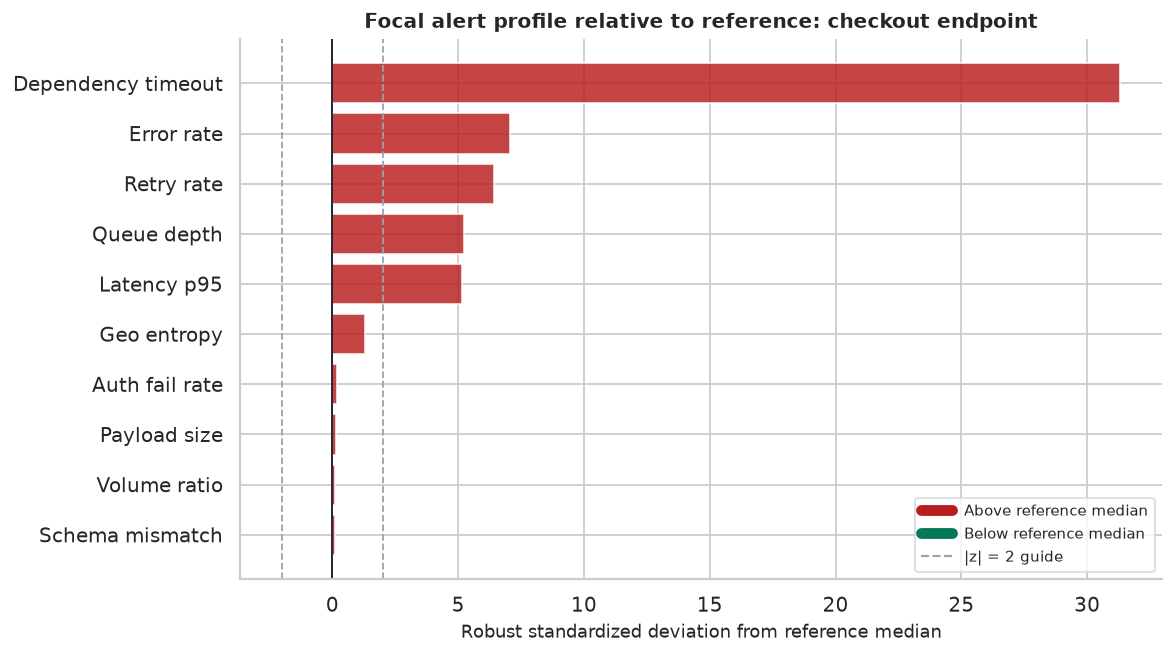

In [7]:
profile_plot = peer_table.sort_values('robust_z_reference')
colors = np.where(profile_plot['robust_z_reference'] >= 0, PALETTE['positive'], PALETTE['negative'])

fig, ax = plt.subplots(figsize=(9.2, 5.2))
ax.barh(profile_plot['feature'], profile_plot['robust_z_reference'], color=colors, alpha=0.82)
ax.axvline(0, color='#111827', linewidth=1.0)
ax.axvline(2, color='#9ca3af', linestyle='--', linewidth=1.0)
ax.axvline(-2, color='#9ca3af', linestyle='--', linewidth=1.0)
ax.set_title(f'Focal alert profile relative to reference: {focal["endpoint"]} endpoint')
ax.set_xlabel('Robust standardized deviation from reference median')
ax.set_ylabel('')
legend_handles = [
    Line2D([0], [0], color=PALETTE['positive'], lw=6, label='Above reference median'),
    Line2D([0], [0], color=PALETTE['negative'], lw=6, label='Below reference median'),
    Line2D([0], [0], color='#9ca3af', lw=1.2, linestyle='--', label='|z| = 2 guide'),
]
ax.legend(handles=legend_handles, loc='lower right', frameon=True, facecolor='white', edgecolor='#d1d5db')
sns.despine(fig=fig)
plt.tight_layout()
plt.show()

This plot is often more useful to an analyst than a global feature-importance chart. It says what is unusual for this specific alert. The same score can mean different things for different endpoints; peer context prevents generic explanations from becoming misleading.

Peer Comparison: Abnormal Relative to What? is less about the score itself and more about whether the score creates an actionable investigation path.


## 8. Exact Contributions for the Transparent Distance Component

The robust distance component is additive in squared standardized deviations. This means we can compute exact contribution shares for that part of the score:

$$
q_j(x_0) = \frac{w_j z_{0j}^{2}}{\sum_{\ell} w_{\ell} z_{0\ell}^{2}}.
$$

The contribution share tells us which variables dominate the distance from normal reference behavior. The sign of $z_{0j}$ tells us whether the focal value is above or below the reference median.

In [8]:
z_values = focal_z.loc[feature_cols]
weighted_squares = weights.loc[feature_cols] * (z_values ** 2)
contrib_share = weighted_squares / weighted_squares.sum()
contrib_table = pd.DataFrame({
    'feature': [feature_names[f] for f in feature_cols],
    'raw_feature': feature_cols,
    'area': [feature_area[f] for f in feature_cols],
    'robust_z': z_values.values,
    'weight': weights.loc[feature_cols].values,
    'weighted_squared_deviation': weighted_squares.values,
    'contribution_share': contrib_share.values,
    'direction': np.where(z_values.values >= 0, 'above reference median', 'below reference median'),
    'actionability': [feature_actionability[f] for f in feature_cols],
}).sort_values('contribution_share', ascending=False)

smart_display(contrib_table.drop(columns=['raw_feature']).head(10).style.format({
    'robust_z': '{:.2f}',
    'weight': '{:.2f}',
    'weighted_squared_deviation': '{:.2f}',
    'contribution_share': '{:.1%}',
}), max_width='540px')

,feature,area,robust_z,weight,weighted_squared_deviation,contribution_share,direction,actionability
8,Dependency timeout,Reliability,31.32,1.25,1225.94,88.6%,above reference median,Inspect dependency health
1,Error rate,Reliability,7.07,1.20,59.97,4.3%,above reference median,Diagnostic
2,Retry rate,Reliability,6.43,1.05,43.36,3.1%,above reference median,Diagnostic
0,Latency p95,Reliability,5.14,1.10,29.11,2.1%,above reference median,Diagnostic
9,Queue depth,Capacity,5.23,0.85,23.28,1.7%,above reference median,Check capacity and backlog
4,Geo entropy,Security,1.28,0.80,1.30,0.1%,above reference median,Investigate traffic source
3,Auth fail rate,Security,0.17,1.25,0.04,0.0%,above reference median,Investigate security controls
7,Payload size,Data quality,0.16,0.85,0.02,0.0%,above reference median,Inspect payload source and contract
6,Schema mismatch,Data quality,0.09,1.25,0.01,0.0%,above reference median,Inspect upstream schema contract
5,Volume ratio,Demand context,0.11,0.75,0.01,0.0%,above reference median,Check release or campaign calendar


Treat this result as an alerting diagnostic. In Exact Contributions for the Transparent Distance Component, the important question is whether the score separates real operational risk from routine variation, measurement noise, or known seasonality. A standout segment should become a concrete triage question.


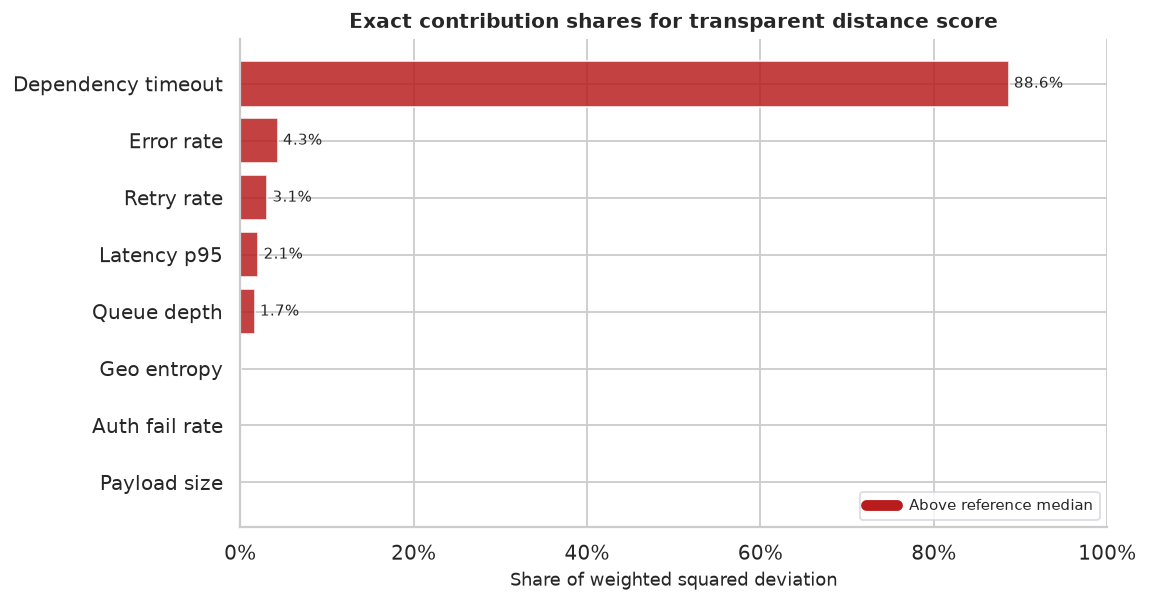

In [9]:
plot_contrib = contrib_table.head(8).sort_values('contribution_share')
contrib_colors = np.where(plot_contrib['direction'].eq('above reference median'), PALETTE['positive'], PALETTE['negative'])

fig, ax = plt.subplots(figsize=(9.0, 4.8))
bars = ax.barh(plot_contrib['feature'], plot_contrib['contribution_share'], color=contrib_colors, alpha=0.84)
ax.set_title('Exact contribution shares for transparent distance score')
ax.set_xlabel('Share of weighted squared deviation')
ax.set_ylabel('')
ax.xaxis.set_major_formatter(lambda x, pos: f'{x:.0%}')
ax.set_xlim(0, min(1.0, plot_contrib['contribution_share'].max() * 1.18))
for bar, share in zip(bars, plot_contrib['contribution_share']):
    x = bar.get_width()
    if share >= 0.01:
        ax.text(x + 0.006, bar.get_y() + bar.get_height() / 2, f'{share:.1%}', va='center', fontsize=8.5)
legend_handles = []
if plot_contrib['direction'].eq('above reference median').any():
    legend_handles.append(Line2D([0], [0], color=PALETTE['positive'], lw=6, label='Above reference median'))
if plot_contrib['direction'].eq('below reference median').any():
    legend_handles.append(Line2D([0], [0], color=PALETTE['negative'], lw=6, label='Below reference median'))
ax.legend(handles=legend_handles, loc='lower right', frameon=True, facecolor='white', edgecolor='#d1d5db')
sns.despine(fig=fig)
plt.tight_layout()
plt.show()

This contribution plot is faithful to the transparent distance component. It is not an approximation. But it explains only one component of the combined score. It also says nothing by itself about causal order. If queue depth and latency both appear, the plot does not prove whether backlog caused latency or latency caused backlog.

## 9. Local Surrogate Explanation for the Combined Score

The combined score includes an Isolation Forest component, which is not naturally additive in the original feature space. To explain the combined score locally, we will perturb the focal alert, score the perturbations, and fit a weighted ridge regression around the focal point.

The perturbations below are deliberately narrow. A local surrogate is meant to explain the score surface near one alert, not to become a global model of all possible endpoint behavior.

This is a local model-agnostic explanation. It should be reported with a **local fidelity** diagnostic, because a poor surrogate should not be trusted.

In [10]:
# Section focus: 9. Local Surrogate Explanation for the Combined Score.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def weighted_r2(y_true, y_pred, weights_):
    """Carry out the weighted r2 step used in the 14. Explaining Anomaly Scores workflow.
    
    Parameters
    ----------
    y_true : object
        Observed target or outcome values used as ground truth for metric calculation.
    y_pred : object
        Predicted target or outcome values compared against the observed values.
    weights_ : object
        The weights  setting that controls the weighted r2 calculation in this notebook.
    
    Returns
    -------
    object
        Numeric diagnostic, score, or transformed value from the weighted r2 calculation.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    weights_ = np.asarray(weights_)
    y_bar = np.average(y_true, weights=weights_)
    ss_res = np.sum(weights_ * (y_true - y_pred) ** 2)
    ss_tot = np.sum(weights_ * (y_true - y_bar) ** 2)
    return 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

x0 = focal_z.loc[feature_cols].to_numpy(dtype=float)
local_rng = np.random.default_rng(RANDOM_SEED + 71)

# A narrow perturbation cloud keeps the explanation genuinely local.
peer_z = scaler.transform(peer_reference[feature_cols])
local_step_scale = 0.18
scales = np.full(len(feature_cols), local_step_scale)
perturb = local_rng.normal(loc=x0, scale=scales, size=(2600, len(feature_cols)))
perturb = np.clip(perturb, -40, 40)
X_local = np.vstack([perturb, x0.reshape(1, -1)])
y_local = score_from_z(X_local)

dist_to_x0 = np.linalg.norm(X_local - x0, axis=1)
kernel_width = np.sqrt(len(feature_cols)) * local_step_scale * 1.8
local_weights = np.exp(-(dist_to_x0 ** 2) / (2 * kernel_width ** 2))
local_weights[-1] = local_weights.max() * 3

surrogate = Ridge(alpha=0.01)
surrogate.fit(X_local, y_local, sample_weight=local_weights)
y_hat = surrogate.predict(X_local)
local_fidelity = weighted_r2(y_local, y_hat, local_weights)

local_coef = pd.DataFrame({
    'feature': [feature_names[f] for f in feature_cols],
    'raw_feature': feature_cols,
    'area': [feature_area[f] for f in feature_cols],
    'local_slope': surrogate.coef_,
    'focal_z': x0,
    'slope_times_focal_z': surrogate.coef_ * x0,
    'abs_local_effect': np.abs(surrogate.coef_ * x0),
    'actionability': [feature_actionability[f] for f in feature_cols],
}).sort_values('abs_local_effect', ascending=False)

fidelity_table = pd.DataFrame([
    {
        'local_surrogate_model': 'Weighted ridge regression around focal alert',
        'perturbations': len(X_local),
        'kernel_width': kernel_width,
        'weighted_local_r2': local_fidelity,
        'focal_true_score': focal['anomaly_score'],
        'focal_surrogate_score': surrogate.predict(x0.reshape(1, -1))[0],
    }
])

smart_display(fidelity_table.style.format({
    'kernel_width': '{:.2f}',
    'weighted_local_r2': '{:.3f}',
    'focal_true_score': '{:.2f}',
    'focal_surrogate_score': '{:.2f}',
}), max_width='520px')
smart_display(local_coef.drop(columns=['raw_feature']).head(10).style.format({
    'local_slope': '{:.3f}',
    'focal_z': '{:.2f}',
    'slope_times_focal_z': '{:.2f}',
    'abs_local_effect': '{:.2f}',
}), max_width='540px')

,local_surrogate_model,perturbations,kernel_width,weighted_local_r2,focal_true_score,focal_surrogate_score
0,Weighted ridge regression around focal alert,2601,1.02,0.939,18.86,18.86


,feature,area,local_slope,focal_z,slope_times_focal_z,abs_local_effect,actionability
8,Dependency timeout,Reliability,0.408,31.32,12.77,12.77,Inspect dependency health
9,Queue depth,Capacity,0.179,5.23,0.94,0.94,Check capacity and backlog
1,Error rate,Reliability,0.090,7.07,0.64,0.64,Diagnostic
2,Retry rate,Reliability,0.072,6.43,0.46,0.46,Diagnostic
0,Latency p95,Reliability,0.059,5.14,0.30,0.30,Diagnostic
4,Geo entropy,Security,0.126,1.28,0.16,0.16,Investigate traffic source
5,Volume ratio,Demand context,0.115,0.11,0.01,0.01,Check release or campaign calendar
3,Auth fail rate,Security,0.020,0.17,0.00,0.00,Investigate security controls
6,Schema mismatch,Data quality,0.036,0.09,0.00,0.00,Inspect upstream schema contract
7,Payload size,Data quality,0.005,0.16,0.00,0.00,Inspect payload source and contract


Read Local Surrogate Explanation for the Combined Score with the reviewer in mind. The detector should clarify where attention is warranted.


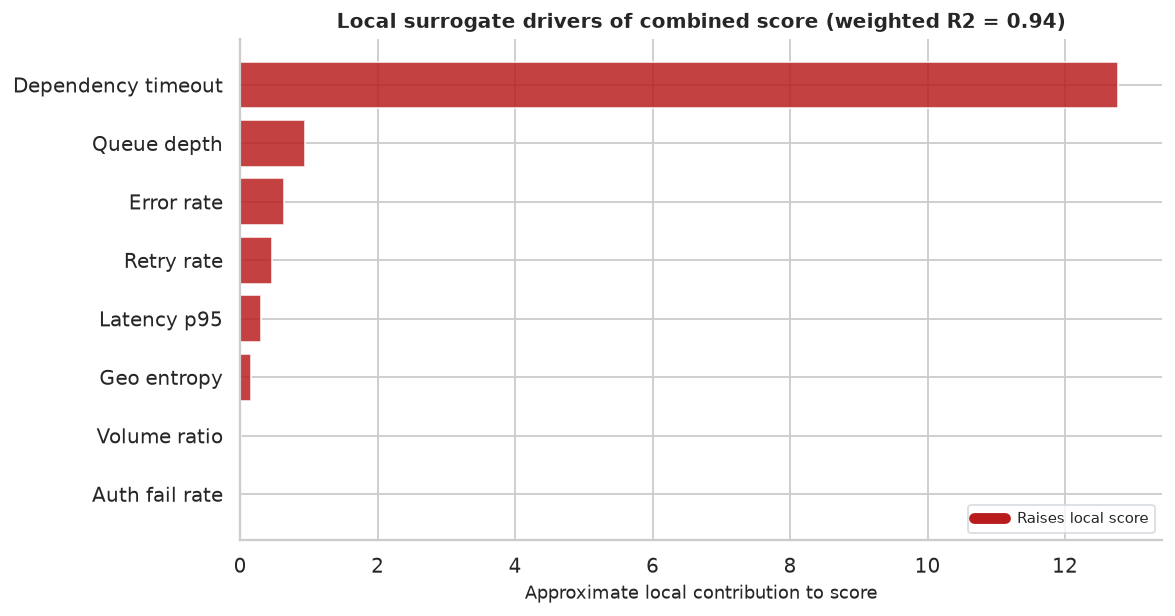

In [11]:
plot_local = local_coef.head(8).sort_values('slope_times_focal_z')
colors = np.where(plot_local['slope_times_focal_z'] >= 0, PALETTE['positive'], PALETTE['negative'])

fig, ax = plt.subplots(figsize=(9.2, 4.9))
ax.barh(plot_local['feature'], plot_local['slope_times_focal_z'], color=colors, alpha=0.84)
ax.axvline(0, color='#111827', linewidth=1.0)
ax.set_title(f'Local surrogate drivers of combined score (weighted R2 = {local_fidelity:.2f})')
ax.set_xlabel('Approximate local contribution to score')
ax.set_ylabel('')
legend_handles = []
if (plot_local['slope_times_focal_z'] >= 0).any():
    legend_handles.append(Line2D([0], [0], color=PALETTE['positive'], lw=6, label='Raises local score'))
if (plot_local['slope_times_focal_z'] < 0).any():
    legend_handles.append(Line2D([0], [0], color=PALETTE['negative'], lw=6, label='Lowers local score'))
ax.legend(handles=legend_handles, loc='lower right', frameon=True, facecolor='white', edgecolor='#d1d5db')
sns.despine(fig=fig)
plt.tight_layout()
plt.show()

The exact distance decomposition and the local surrogate answer related but different questions.

- The **distance decomposition** explains a transparent score component exactly.
- The **local surrogate** approximates the full combined score near one alert.

If these two views broadly agree, confidence in the explanation increases. If they disagree, that may reflect the black-box component is using interactions, thresholds, or isolation patterns that are not captured by simple distance.

## 10. Counterfactual Movement Toward the Threshold

A counterfactual threshold diagnostic asks:

$$
\text{Which changes toward normal reference behavior would move } s(x_0) \text{ below } \tau?
$$

This is useful for understanding threshold proximity, but it is not a root-cause intervention. Some features are outcomes of a failure, some are symptoms, and some are not directly controllable.

In [12]:
# Section focus: 10. Counterfactual Movement Toward the Threshold.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

peer_z_median = pd.DataFrame(peer_z, columns=feature_cols).median()
current_z = pd.Series(x0.copy(), index=feature_cols)
current_score = score_from_z(current_z.to_numpy().reshape(1, -1))[0]

counterfactual_rows = []
path_rows = [{'step': 0, 'changed_feature': 'current alert', 'score': current_score, 'below_threshold': current_score < threshold}]
z_cf = current_z.copy()

for step, feature in enumerate(local_coef['raw_feature'].head(8), start=1):
    previous_score = score_from_z(z_cf.to_numpy().reshape(1, -1))[0]
    old_value = z_cf[feature]
    z_cf[feature] = peer_z_median[feature]
    new_score = score_from_z(z_cf.to_numpy().reshape(1, -1))[0]
    counterfactual_rows.append({
        'step': step,
        'feature_moved_toward_peer_median': feature_names[feature],
        'area': feature_area[feature],
        'original_robust_z': old_value,
        'peer_median_robust_z': peer_z_median[feature],
        'score_before_step': previous_score,
        'score_after_step': new_score,
        'score_reduction': previous_score - new_score,
        'below_threshold_after_step': new_score < threshold,
        'caveat': feature_actionability[feature],
    })
    path_rows.append({
        'step': step,
        'changed_feature': feature_names[feature],
        'score': new_score,
        'below_threshold': new_score < threshold,
    })
    if new_score < threshold:
        break

counterfactual_table = pd.DataFrame(counterfactual_rows)
path_table = pd.DataFrame(path_rows)

smart_display(counterfactual_table.style.format({
    'original_robust_z': '{:.2f}',
    'peer_median_robust_z': '{:.2f}',
    'score_before_step': '{:.2f}',
    'score_after_step': '{:.2f}',
    'score_reduction': '{:.2f}',
}), max_width='540px')

,step,feature_moved_toward_peer_median,area,original_robust_z,peer_median_robust_z,score_before_step,score_after_step,score_reduction,below_threshold_after_step,caveat
0,1,Dependency timeout,Reliability,31.32,-0.05,18.86,8.45,10.41,False,Inspect dependency health
1,2,Queue depth,Capacity,5.23,0.12,8.45,7.17,1.29,False,Check capacity and backlog
2,3,Error rate,Reliability,7.07,0.02,7.17,4.83,2.34,False,Diagnostic
3,4,Retry rate,Reliability,6.43,-0.03,4.83,1.93,2.89,True,Diagnostic


In Counterfactual Movement Toward the Threshold, the useful signal is the part that survives contact with seasonality, measurement noise, and routine variation.


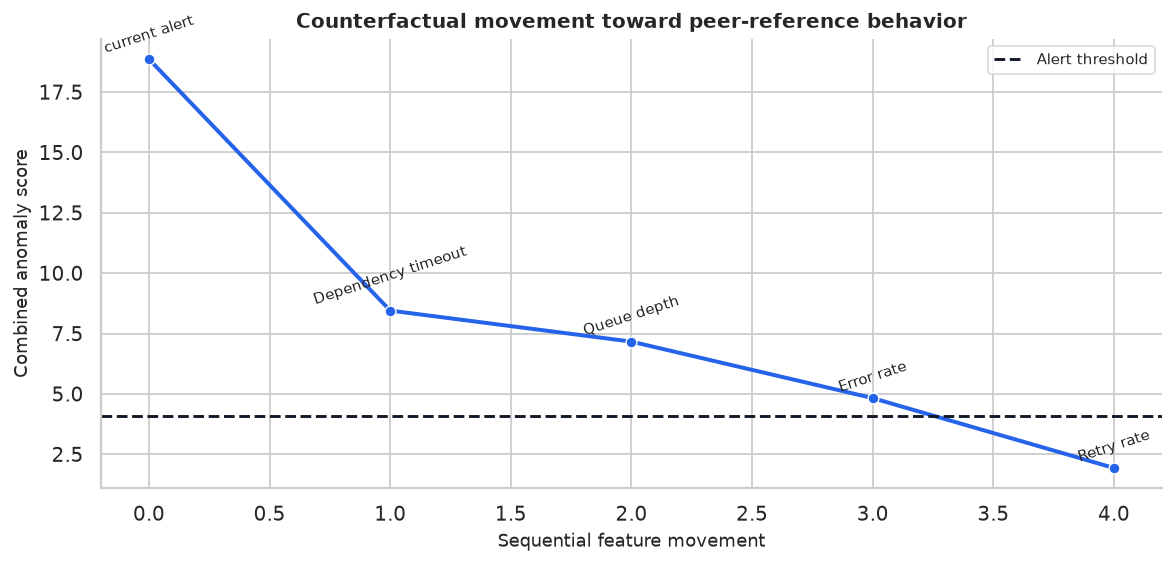

In [13]:
fig, ax = plt.subplots(figsize=(9.2, 4.5))
sns.lineplot(data=path_table, x='step', y='score', marker='o', color=PALETTE['score'], linewidth=2.2, ax=ax)
ax.axhline(threshold, color=PALETTE['threshold'], linestyle='--', linewidth=1.6, label='Alert threshold')
for _, row in path_table.iterrows():
    ax.text(row['step'], row['score'] + 0.12, row['changed_feature'], ha='center', va='bottom', fontsize=8.2, rotation=18)
ax.set_title('Counterfactual movement toward peer-reference behavior')
ax.set_xlabel('Sequential feature movement')
ax.set_ylabel('Combined anomaly score')
ax.legend(frameon=True, facecolor='white', edgecolor='#d1d5db')
sns.despine(fig=fig)
plt.tight_layout()
plt.show()

This path is a model diagnostic. It tells us which feature movements would reduce the score fastest under the current detector. It does not say the organization can directly set those features. For example, reducing dependency timeouts may require fixing an upstream service; reducing queue depth may require capacity changes; reducing geographic entropy may require security controls.

A professional explanation should therefore state the actionability caveat next to every feature movement.

## 11. Explanation Stability

Explanations are less useful when tiny changes in the local neighborhood change the top drivers. We will refit the local surrogate under several random perturbation seeds and track how often each feature appears among the top three local drivers.

In [14]:
# Section focus: 11. Explanation Stability.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def local_surrogate_for_seed(seed, n_perturb=900):
    """Carry out the local surrogate for seed step used in the 14. Explaining Anomaly Scores workflow.
    
    Parameters
    ----------
    seed : object
        Random seed used to make the simulation reproducible.
    n_perturb : object
        Count or size setting for the local surrogate for seed calculation.
    
    Returns
    -------
    object
        pandas.DataFrame containing the tabular result produced by this function.
    """
    local_rng = np.random.default_rng(seed)
    perturb = local_rng.normal(loc=x0, scale=scales, size=(n_perturb, len(feature_cols)))
    perturb = np.clip(perturb, -40, 40)
    X_local_seed = np.vstack([perturb, x0.reshape(1, -1)])
    y_seed = score_from_z(X_local_seed)
    dist_seed = np.linalg.norm(X_local_seed - x0, axis=1)
    weights_seed = np.exp(-(dist_seed ** 2) / (2 * kernel_width ** 2))
    weights_seed[-1] = weights_seed.max() * 3
    model = Ridge(alpha=0.01)
    model.fit(X_local_seed, y_seed, sample_weight=weights_seed)
    effect = model.coef_ * x0
    return pd.DataFrame({
        'seed': seed,
        'feature': feature_cols,
        'feature_label': [feature_names[f] for f in feature_cols],
        'local_effect': effect,
        'abs_local_effect': np.abs(effect),
    })

stability_runs = pd.concat([local_surrogate_for_seed(RANDOM_SEED + 200 + s) for s in range(25)], ignore_index=True)
stability_runs['rank'] = stability_runs.groupby('seed')['abs_local_effect'].rank(method='first', ascending=False)

stability_summary = (
    stability_runs.assign(top3=lambda d: d['rank'].le(3))
    .groupby(['feature', 'feature_label'])
    .agg(
        top3_frequency=('top3', 'mean'),
        mean_local_effect=('local_effect', 'mean'),
        sd_local_effect=('local_effect', 'std'),
    )
    .reset_index()
    .sort_values('top3_frequency', ascending=False)
)

smart_display(stability_summary.head(10).style.format({
    'top3_frequency': '{:.0%}',
    'mean_local_effect': '{:.2f}',
    'sd_local_effect': '{:.2f}',
}), max_width='520px')

,feature,feature_label,top3_frequency,mean_local_effect,sd_local_effect
1,dependency_timeout_pct,Dependency timeout,100%,12.89,0.14
2,error_rate_pct,Error rate,100%,0.64,0.03
6,queue_depth,Queue depth,100%,0.93,0.03
0,auth_fail_rate_pct,Auth fail rate,0%,0.00,0.00
4,latency_p95_ms,Latency p95,0%,0.31,0.02
3,geo_entropy,Geo entropy,0%,0.16,0.01
5,payload_mb,Payload size,0%,0.00,0.00
7,retry_rate_pct,Retry rate,0%,0.46,0.02
8,schema_mismatch_pct,Schema mismatch,0%,0.00,0.00
9,volume_ratio,Volume ratio,0%,0.01,0.00


For Explanation Stability, focus on what the alert would make an analyst do next: investigate, suppress, monitor, or revise the rule.


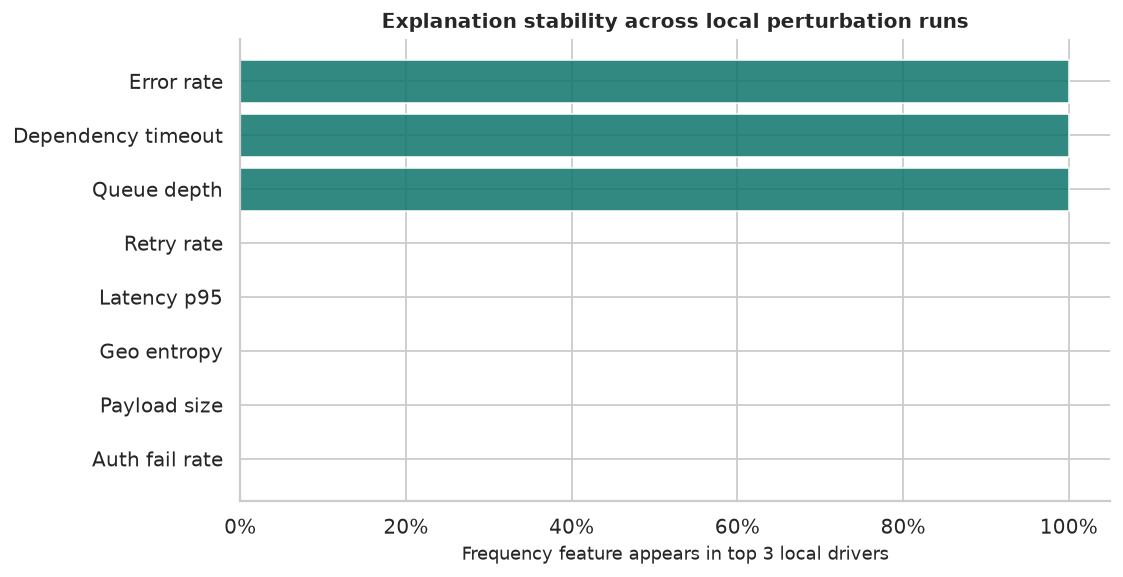

In [15]:
plot_stability = stability_summary.head(8).sort_values('top3_frequency')
fig, ax = plt.subplots(figsize=(8.8, 4.6))
ax.barh(plot_stability['feature_label'], plot_stability['top3_frequency'], color='#0f766e', alpha=0.86)
ax.set_title('Explanation stability across local perturbation runs')
ax.set_xlabel('Frequency feature appears in top 3 local drivers')
ax.set_ylabel('')
ax.xaxis.set_major_formatter(lambda x, pos: f'{x:.0%}')
sns.despine(fig=fig)
plt.tight_layout()
plt.show()

Stability does not prove correctness, but instability is a warning sign. If the top features change dramatically across local perturbation samples, the explanation should be communicated as tentative. Stable explanations are easier to review, reproduce, and challenge.

Explanation Stability should be read as an operations question. A useful score separates review-worthy risk from ordinary variation.


## 12. Analyst-Facing Explanation Packet

The final artifact should be compact enough for triage but rich enough for audit. It should name the score, threshold, key drivers, peer context, caveats, and suggested next action.

In [16]:
# Section focus: 12. Analyst-Facing Explanation Packet.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

top_distance = contrib_table.head(3)
top_surrogate = local_coef.head(3)
first_below = path_table[path_table['below_threshold']]
if len(first_below):
    threshold_statement = f"Score falls below threshold after {int(first_below.iloc[0]['step'])} feature movement(s) toward peer medians."
else:
    threshold_statement = 'Score remains above threshold after the tested feature movements.'

def join_features(table, feature_col='feature'):
    """Carry out the join features step used in the 14. Explaining Anomaly Scores workflow.
    
    Parameters
    ----------
    table : object
        Tabular result used by this calculation or plot.
    feature_col : object
        Column or variable name used to select information from the input table.
    
    Returns
    -------
    object
        Tabular or matrix-style object produced by the join features workflow for later analysis.
    """
    return '; '.join(table[feature_col].tolist())

packet = pd.DataFrame([
    {
        'packet_item': 'Alert status',
        'content': f"Score {focal['anomaly_score']:.2f} exceeds threshold {threshold:.2f}; endpoint={focal['endpoint']}; region={focal['region']}.",
    },
    {
        'packet_item': 'Main transparent-score drivers',
        'content': join_features(top_distance),
    },
    {
        'packet_item': 'Main local-surrogate drivers',
        'content': join_features(top_surrogate),
    },
    {
        'packet_item': 'Peer comparison',
        'content': f"Compared against {len(peer_reference)} reference rows from the same endpoint where possible; strongest peer-percentile deviations are {join_features(peer_table.head(3))}.",
    },
    {
        'packet_item': 'Threshold diagnostic',
        'content': threshold_statement,
    },
    {
        'packet_item': 'Causal caveat',
        'content': 'Feature contributions explain the score, not the physical root cause. Use traces, logs, deployment history, and system ownership to confirm cause.',
    },
    {
        'packet_item': 'Recommended review action',
        'content': 'Escalate to the owning reliability/security/data-quality queue indicated by the top drivers; attach peer comparison and counterfactual table to the ticket.',
    },
])
smart_display(packet, max_width='620px')

,packet_item,content
0,Alert status,Score 18.86 exceeds threshold 4.10; endpoint=checkout; region=apac.
1,Main transparent-score drivers,Dependency timeout; Error rate; Retry rate
2,Main local-surrogate drivers,Dependency timeout; Queue depth; Error rate
3,Peer comparison,Compared against 687 reference rows from the same endpoint where possible; strongest peer-percentile deviations are Dependency timeout; Error rate; Retry rate.
4,Threshold diagnostic,Score falls below threshold after 4 feature movement(s) toward peer medians.
5,Causal caveat,"Feature contributions explain the score, not the physical root cause. Use traces, logs, deployment history, and system ownership to confirm cause."
6,Recommended review action,Escalate to the owning reliability/security/data-quality queue indicated by the top drivers; attach peer comparison and counterfactual table to the ticket.


The packet is intentionally not a story that overstates certainty. It is an evidence bundle. It tells the reviewer what made the score high, why the case is unusual relative to peers, what could move the score below threshold, and what evidence is still needed before claiming root cause.

## 13. Practical Checklist for Explaining Anomaly Scores

| Checklist item | Why it matters |
|---|---|
| Report score and threshold together | A score without a decision rule is hard to interpret |
| Include peer group definition | The same value can be normal for one segment and abnormal for another |
| Separate exact and approximate explanations | Exact decompositions and surrogate explanations have different reliability |
| Report local fidelity | A local surrogate with poor fit should not be trusted |
| Include actionability caveats | Not every score driver is directly controllable |
| Check explanation stability | Fragile explanations should be communicated as tentative |
| Avoid causal language unless justified | Score drivers require causal evidence before being treated as causes |
| Link explanation to workflow | The explanation should support review, escalation, suppression, or redesign |

## 14. Key Takeaways

- An anomaly explanation should explain the **score**, **threshold gap**, **peer context**, and **workflow implication**.
- Transparent scores can often be decomposed exactly, while black-box scores usually require approximate explanation methods.
- Local surrogate explanations are useful only when local fidelity is adequate and the perturbation design is sensible.
- Counterfactual threshold diagnostics help analysts understand score proximity, but they are not causal recourse plans.
- Explanation stability should be checked because unstable explanations can undermine operational trust.
- The best explanation packet is modest: it guides investigation without pretending to prove root cause.

## References

- Chandola, V., Banerjee, A., & Kumar, V. (2009). Anomaly detection. *ACM Computing Surveys, 41*(3), 1-58. [https://doi.org/10.1145/1541880.1541882](https://doi.org/10.1145/1541880.1541882)
- Kim, D., Antariksa, G., Handayani, M. P., Lee, J., & Lee, J. (2021). Explainable anomaly detection framework for maritime main engine sensor data. *Sensors, 21*(15), 5200. [https://doi.org/10.3390/s21155200](https://doi.org/10.3390/s21155200)
- Liu, F. T., Ting, K. M., & Zhou, Z.-H. (2008). Isolation Forest. *IEEE International Conference on Data Mining*, 413-422. [https://doi.org/10.1109/ICDM.2008.17](https://doi.org/10.1109/ICDM.2008.17)
- Lundberg, S. M., & Lee, S.-I. (2017). A unified approach to interpreting model predictions. *arXiv*. [https://doi.org/10.48550/arxiv.1705.07874](https://doi.org/10.48550/arxiv.1705.07874)
- Rad, B., Song, F., Jacob, V., & Diao, Y. (2021). Explainable anomaly detection on high-dimensional time series data. *ACM International Conference Proceeding Series*, 2-14. [https://doi.org/10.1145/3465480.3468292](https://doi.org/10.1145/3465480.3468292)
- Ribeiro, M. T., Singh, S., & Guestrin, C. (2016). "Why should I trust you?": Explaining the predictions of any classifier. *Proceedings of NAACL-HLT Demonstrations*, 97-101. [https://doi.org/10.18653/v1/n16-3020](https://doi.org/10.18653/v1/n16-3020)
